In [4]:
import os 
import numpy as np
import pandas as pd
import random as rn

import tensorflow as tf
import keras

from tensorflow.keras.applications.vgg16 import VGG16,preprocess_input
from tensorflow.keras.models import Sequential

from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.layers import Input, Dense, Conv2D, MaxPool2D,Activation, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, TensorBoard
from tensorflow.keras import regularizers

In [5]:
dir_path='/kaggle/input/datasets/gowtamsingulur/rvlcdip'

In [6]:
os.listdir(dir_path)

['labels_final.csv', 'data_final']

### **Data in Dataframe Format not in directory**

In [7]:
train_df=pd.read_csv('/kaggle/input/datasets/gowtamsingulur/rvlcdip/labels_final.csv')
train_df.head()

,path,label
0,imagesv/v/o/h/voh71d00/509132755+-2755.tif,3
1,imagesl/l/x/t/lxt19d00/502213303.tif,3
2,imagesx/x/e/d/xed05a00/2075325674.tif,2
3,imageso/o/j/b/ojb60d00/517511301+-1301.tif,3
4,imagesq/q/z/k/qzk17e00/2031320195.tif,7


In [8]:
train_df['path'].head()

0    imagesv/v/o/h/voh71d00/509132755+-2755.tif
1          imagesl/l/x/t/lxt19d00/502213303.tif
2         imagesx/x/e/d/xed05a00/2075325674.tif
3    imageso/o/j/b/ojb60d00/517511301+-1301.tif
4         imagesq/q/z/k/qzk17e00/2031320195.tif
Name: path, dtype: object

In [17]:
imarray=np.array(image)
print(imarray.shape)

(1000, 754)


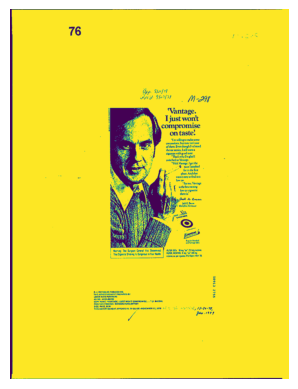

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

# Load and display a .tif image
image_path='/kaggle/input/datasets/gowtamsingulur/rvlcdip/data_final/imagesv/v/o/h/voh71d00/509132755+-2755.tif'
image=Image.open(image_path)

plt.imshow(image)
plt.axis('off')   # Turn off axis labels
plt.show()

In [10]:
train_df['label'].value_counts()

label
0     3016
13    3007
14    3006
12    3006
3     3005
8     3003
9     3002
10    3002
7     3000
5     2999
15    2996
1     2994
4     2994
2     2993
11    2992
6     2985
Name: count, dtype: int64

### **Aplying Data augumentation**

In [11]:
train_datagen=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [12]:
train_generator=train_datagen.flow_from_dataframe(dataframe=train_df,
                                           directory='/kaggle/input/datasets/gowtamsingulur/rvlcdip/data_final',
                                           x_col='path',
                                           y_col='label',
                                           subset='training',
                                           batch_size=100,
                                           seed=42,
                                           shuffle=True,
                                           class_mode='raw',
                                           target_size=(224,224))

Found 38400 validated image filenames.


### While passing the data to training, it will do data augumentation
### It loaded the augumented images during the batch

In [23]:
#images, labels = next(train_generator)
#print(images,labels)

In [22]:
images, labels = next(train_generator)
print(len(images),len(labels))

100 100


In [24]:
print(labels)

[11  5  4  0  0 14  0  3 11 12 11 14  2  2  6  2  0  1  4 10  7  2  4  5
  9  2 12 10  1  4 11 10 14  8  8  7  7  8 10  6 10 10  2  7 13  7  1  5
 14  9  4  4  8 11 15  4  7  4  0  4  8  9  8 11  0  3  3 10 12  3 14 12
 14  0 13 11  8 14  0  1  6  7 14 10 14  2  9  9 10  2  4 15  6 15  5  2
  5 14  8  9]


In [14]:
validate_generator=train_datagen.flow_from_dataframe(dataframe=train_df,
                                           directory='/kaggle/input/datasets/gowtamsingulur/rvlcdip/data_final',
                                           x_col='path',
                                           y_col='label',
                                           subset='validation',
                                           batch_size=100,
                                           seed=42,
                                           shuffle=True,
                                           class_mode='raw',
                                           target_size=(224,224))

Found 9600 validated image filenames.


## Custom CNN Model from Scratch

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

model=Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(16,activation='softmax'),                # Lastly 16 because 16 classes in the data and softmax will return probability of all classes
])

In [34]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,256 (42.64 MB)

 Trainable params: 11,178,256 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
from tensorflow.keras.callbacks import ModelCheckpoint,ReduceLROnPlateau,EarlyStopping,TensorBoard
import os
import datetime

Creating Checkpoint


In [36]:
checkpoint_path='/kaggle/working/model_checkpoints/weights.{epochs:02d}-{val_loss:2f}.keras'
log_dir='/kaggle/working/logs/fit/'+ datetime.datetime.now().strftime('%Y%m%d-%H%M%S')


#Epoch1 - weights.keras
#Epoch2 - weights.keras

# Naming format -> 'weights.{epochs:02d}-{val_loss:2f}.keras'

model_checkpoint=ModelCheckpoint(filepath=checkpoint_path,
                                save_best_only=True,
                                monitor='val_loss',
                                mode='min',
                                verbose=1)
#e1=0.7
#e2=0.6
#when ever there is improvement, I want the model to be saved.

reduce_lr=ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=0.3, min_lr=0.0001)
#e1=0.7
#e2=0.71
#e3=0.72
# then reduce lr or to min
#e4=0.65

early_stop=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
#e1=0.7
#e2=0.71
#e3=0.72
#e4=0.75
#e5=0.8
#Stop the training if it does not reduce after 5
#Restoring the checkpoint

board=TensorBoard(log_dir=log_dir,histogram_freq=1)

callbacks=[model_checkpoint, reduce_lr, early_stop, board]

In [37]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,178,256 (42.64 MB)

 Trainable params: 11,178,256 (42.64 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [ ]:
history=model.fit(
    train_generator,
    validation_data=validate_generator,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
 25/384 ━━━━━━━━━━━━━━━━━━━━ 9:37 2s/step - accuracy: 0.4287 - loss: 1.8195

In [ ]:
tf.keras.models.load()

save and load